# Guía 3 V4 - Notebook completo final corregido

## Aprendizaje supervisado para predicción de abandono de clientes

Este notebook integra el flujo completo de la Guía 3:

1. Carga del dataset.
2. Revisión y normalización de categorías.
3. Separación de variables predictoras y variable objetivo.
4. División entrenamiento/prueba.
5. Codificación y escalamiento dentro de `Pipeline`.
6. Entrenamiento y comparación de modelos.
7. Selección del modelo final.
8. Evaluación con porcentaje de acierto, error, matriz de confusión y métricas.
9. Comparación entrenamiento vs prueba.
10. Prueba con datos nuevos ingresados manualmente.
11. Script opcional para solicitar datos por teclado.

> **Nota importante:** Este notebook corrige el problema del `OrdinalEncoder` cuando `Segmento` aparece como `Basico` o `Básico`. El valor se normaliza internamente para evitar errores durante el entrenamiento.

## 1. Importación de librerías

Se importan las librerías necesarias para cargar datos, entrenar modelos, evaluar resultados y graficar.

- `pandas` permite manipular tablas de datos.
- `matplotlib` permite generar gráficas.
- `scikit-learn` permite dividir datos, crear pipelines, transformar variables y entrenar modelos supervisados.

In [1]:
# ============================================================
# 1. Importación de librerías
# ============================================================

import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. Carga del dataset

El dataset contiene información de clientes y una variable objetivo llamada `Abandono`.

La variable objetivo se interpreta así:

| Valor | Significado |
|---:|---|
| 0 | El cliente no abandonó |
| 1 | El cliente sí abandonó |

El bloque intenta cargar el archivo desde varias rutas posibles. Si el notebook y el archivo `base.csv` están en la misma carpeta, se cargará automáticamente.

In [2]:
# ============================================================
# 2. Carga del dataset
# ============================================================

rutas_posibles = [
    "base.csv",
    "G3V4_base.csv",
    "/mnt/data/G3V4_base.csv",
    r"F:\HMO\SENA\2026\Procesamiento de datos\Final\Guia_3\G3V3_TODO\G3V3_EST\04_notebook\base.csv"
]

df = None
ruta_usada = None

for ruta in rutas_posibles:
    try:
        if os.path.exists(ruta):
            df = pd.read_csv(ruta)
            ruta_usada = ruta
            break
    except Exception as e:
        print(f"No se pudo cargar desde {ruta}. Detalle: {e}")

if df is None:
    raise FileNotFoundError(
        "No se encontró el dataset. Verifica que el archivo base.csv o G3V4_base.csv esté en la misma carpeta del notebook."
    )

print("Dataset cargado desde:", ruta_usada)
print("Dimensiones del dataset:", df.shape)
display(df.head())

Dataset cargado desde: base.csv
Dimensiones del dataset: (420, 18)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono
0,CLI_0001,18,3968,17,5,4,0,39,11,7.72,1,Cali,Tienda,Urbana,Básico,Media,CAMP_10,0
1,CLI_0002,50,3528,18,8,53,1,12,1,5.50,1,Medellin,Telefono,Urbana,Básico,Alta,CAMP_04,0
2,CLI_0003,46,750,16,8,90,1,83,10,6.15,3,Cartagena,Web,Urbana,Básico,Alta,CAMP_09,0
3,CLI_0004,20,4356,21,4,25,3,85,4,10.88,2,Cartagena,Tienda,Rural,Medio,Baja,CAMP_06,1
4,CLI_0005,61,6155,12,4,10,0,21,6,0.51,2,Bogota,Tienda,Urbana,Medio,Alta,CAMP_01,0


## 3. Revisión inicial del dataset

Antes de entrenar un modelo, se revisa la estructura del dataset.

Esta revisión permite responder:

- ¿Cuántas filas y columnas tiene el dataset?
- ¿Qué tipos de datos existen?
- ¿Hay variables numéricas y categóricas?
- ¿Existe la variable objetivo `Abandono`?

Esta etapa evita errores posteriores en la codificación, escalamiento y entrenamiento.

In [3]:
# ============================================================
# 3. Revisión inicial del dataset
# ============================================================

print("Información general del dataset:")
df.info()

print("\nColumnas disponibles:")
print(df.columns.tolist())

Información general del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               420 non-null    object 
 1   Edad                     420 non-null    int64  
 2   IngresoMensual           420 non-null    int64  
 3   CantidadCompras          420 non-null    int64  
 4   ComprasUltimos12M        420 non-null    int64  
 5   AntiguedadMeses          420 non-null    int64  
 6   QuejasUltimos6M          420 non-null    int64  
 7   DiasDesdeUltimaCompra    420 non-null    int64  
 8   VisitasWebUltimoMes      420 non-null    int64  
 9   TiempoPromedioSesionMin  420 non-null    float64
 10  CuponesUsados            420 non-null    int64  
 11  Ciudad                   420 non-null    object 
 12  CanalPreferido           420 non-null    object 
 13  ZonaResidencia           420 non-null    object

## 4. Normalización preventiva de categorías

Este paso es muy importante porque algunos datasets pueden tener categorías escritas de forma diferente.

Ejemplo:

| Forma encontrada | Forma normalizada |
|---|---|
| `Basico` | `Básico` |
| `Bogota` | `Bogotá` |
| `Medellin` | `Medellín` |
| `Telefono` | `Teléfono` |

Esta normalización evita errores como:

```text
ValueError: Found unknown categories ['Básico'] in column 0 during fit
```

Ese error ocurre cuando el `OrdinalEncoder` espera unas categorías, pero el dataset contiene otras escritas de manera diferente.

In [4]:
# ============================================================
# 4. Normalización preventiva de categorías
# ============================================================

def normalizar_categorias_clientes(dataframe):
    """
    Normaliza textos categóricos para evitar errores de codificación.
    Esta función corrige diferencias de tildes, espacios y nombres equivalentes.
    """
    df_norm = dataframe.copy()

    columnas_texto = [
        "Ciudad",
        "CanalPreferido",
        "ZonaResidencia",
        "Segmento",
        "Satisfaccion",
        "CodigoCampania"
    ]

    for col in columnas_texto:
        if col in df_norm.columns:
            df_norm[col] = df_norm[col].astype(str).str.strip()

    if "Segmento" in df_norm.columns:
        df_norm["Segmento"] = df_norm["Segmento"].replace({
            "Basico": "Básico",
            "basico": "Básico",
            "BASICO": "Básico",
            "básico": "Básico",
            "BÁSICO": "Básico",
            "Medio": "Medio",
            "medio": "Medio",
            "MEDIO": "Medio",
            "Premium": "Premium",
            "premium": "Premium",
            "PREMIUM": "Premium"
        })

    if "Satisfaccion" in df_norm.columns:
        df_norm["Satisfaccion"] = df_norm["Satisfaccion"].replace({
            "Baja": "Baja",
            "baja": "Baja",
            "BAJA": "Baja",
            "Media": "Media",
            "media": "Media",
            "MEDIA": "Media",
            "Alta": "Alta",
            "alta": "Alta",
            "ALTA": "Alta"
        })

    if "Ciudad" in df_norm.columns:
        df_norm["Ciudad"] = df_norm["Ciudad"].replace({
            "Bogota": "Bogotá",
            "BOGOTA": "Bogotá",
            "bogota": "Bogotá",
            "Medellin": "Medellín",
            "MEDELLIN": "Medellín",
            "medellin": "Medellín"
        })

    if "CanalPreferido" in df_norm.columns:
        df_norm["CanalPreferido"] = df_norm["CanalPreferido"].replace({
            "Telefono": "Teléfono",
            "telefono": "Teléfono",
            "TELEFONO": "Teléfono",
            "Tienda": "Tienda física",
            "Tienda Fisica": "Tienda física",
            "Tienda fisica": "Tienda física",
            "tienda": "Tienda física",
            "Redes": "Redes sociales",
            "redes": "Redes sociales"
        })

    return df_norm

df = normalizar_categorias_clientes(df)

print("Valores únicos normalizados en Segmento:")
print(df["Segmento"].unique())

print("\nValores únicos normalizados en Satisfaccion:")
print(df["Satisfaccion"].unique())

print("\nValores únicos normalizados en Ciudad:")
print(df["Ciudad"].unique())

print("\nValores únicos normalizados en CanalPreferido:")
print(df["CanalPreferido"].unique())

Valores únicos normalizados en Segmento:
['Básico' 'Medio' 'Premium']

Valores únicos normalizados en Satisfaccion:
['Media' 'Alta' 'Baja']

Valores únicos normalizados en Ciudad:
['Cali' 'Medellín' 'Cartagena' 'Bogotá' 'Barranquilla']

Valores únicos normalizados en CanalPreferido:
['Tienda física' 'Teléfono' 'Web' 'App']


## 5. Diagnóstico de la variable objetivo

La variable objetivo es `Abandono`.

En este bloque se calcula cuántos clientes abandonaron y cuántos no. Esto permite revisar si existe desbalance de clases.

Conteo de clases:
Abandono
0    240
1    180
Name: count, dtype: int64

Proporción de clases:
Abandono
0    57.14%
1    42.86%
Name: proportion, dtype: object


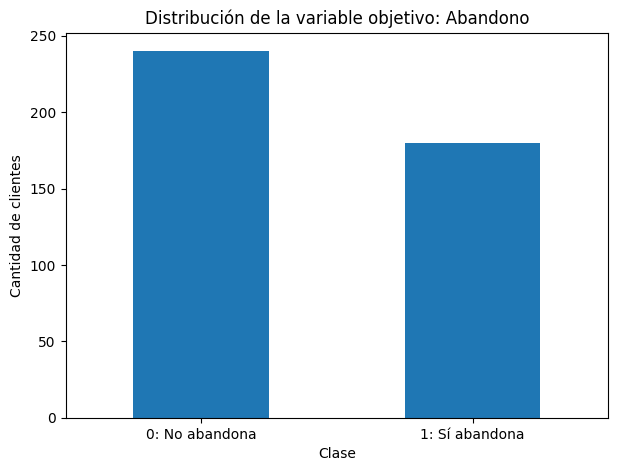

In [5]:
# ============================================================
# 5. Diagnóstico de la variable objetivo
# ============================================================

objetivo = "Abandono"

print("Conteo de clases:")
print(df[objetivo].value_counts())

print("\nProporción de clases:")
print((df[objetivo].value_counts(normalize=True) * 100).round(2).astype(str) + "%")

plt.figure(figsize=(7, 5))
df[objetivo].value_counts().sort_index().plot(kind="bar")
plt.title("Distribución de la variable objetivo: Abandono")
plt.xlabel("Clase")
plt.ylabel("Cantidad de clientes")
plt.xticks(ticks=[0, 1], labels=["0: No abandona", "1: Sí abandona"], rotation=0)
plt.show()

## 6. Separación entre variables predictoras y variable objetivo

El modelo necesita dos elementos:

| Elemento | Significado |
|---|---|
| `X` | Variables predictoras: datos que usa el modelo para aprender |
| `y` | Variable objetivo: respuesta que el modelo debe predecir |

Se excluyen:

- `Abandono`, porque es la respuesta.
- `ID_Cliente`, porque es un identificador y no describe comportamiento del cliente.

Incluir `Abandono` dentro de `X` sería una fuga de información.

In [6]:
# ============================================================
# 6. Separación entre X e y
# ============================================================

columnas_a_excluir = ["Abandono", "ID_Cliente"]

X = df.drop(columns=columnas_a_excluir)
y = df["Abandono"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nColumnas predictoras:")
print(X.columns.tolist())

Dimensiones de X: (420, 16)
Dimensiones de y: (420,)

Columnas predictoras:
['Edad', 'IngresoMensual', 'CantidadCompras', 'ComprasUltimos12M', 'AntiguedadMeses', 'QuejasUltimos6M', 'DiasDesdeUltimaCompra', 'VisitasWebUltimoMes', 'TiempoPromedioSesionMin', 'CuponesUsados', 'Ciudad', 'CanalPreferido', 'ZonaResidencia', 'Segmento', 'Satisfaccion', 'CodigoCampania']


## 7. División en entrenamiento y prueba

El dataset se divide en dos partes:

| Conjunto | Uso |
|---|---|
| Entrenamiento | El modelo aprende patrones |
| Prueba | Se evalúa el modelo con datos no vistos |

Se usa `stratify=y` para mantener proporciones similares de abandono/no abandono en ambos conjuntos.

In [7]:
# ============================================================
# 7. División entrenamiento/prueba
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)

print("\nDistribución en entrenamiento:")
print((y_train.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

print("\nDistribución en prueba:")
print((y_test.value_counts(normalize=True) * 100).round(2).astype(str) + "%")

Tamaño de X_train: (336, 16)
Tamaño de X_test: (84, 16)

Distribución en entrenamiento:
Abandono
0    57.14%
1    42.86%
Name: proportion, dtype: object

Distribución en prueba:
Abandono
0    57.14%
1    42.86%
Name: proportion, dtype: object


## 8. Clasificación de variables para el preprocesamiento

Antes de entrenar modelos se define cómo tratar cada tipo de variable.

| Tipo de variable | Tratamiento |
|---|---|
| Numéricas | Escalamiento con `StandardScaler` |
| Categóricas nominales | `OneHotEncoder` |
| Categóricas ordinales | `OrdinalEncoder` respetando el orden |

Orden definido para variables ordinales:

- `Segmento`: **Básico < Medio < Premium**
- `Satisfaccion`: **Baja < Media < Alta**

In [8]:
# ============================================================
# 8. Clasificación de variables
# ============================================================

columnas_numericas = [
    "Edad",
    "IngresoMensual",
    "CantidadCompras",
    "ComprasUltimos12M",
    "AntiguedadMeses",
    "QuejasUltimos6M",
    "DiasDesdeUltimaCompra",
    "VisitasWebUltimoMes",
    "TiempoPromedioSesionMin",
    "CuponesUsados"
]

columnas_nominales = [
    "Ciudad",
    "CanalPreferido",
    "ZonaResidencia",
    "CodigoCampania"
]

columnas_ordinales = [
    "Segmento",
    "Satisfaccion"
]

print("Variables numéricas:", columnas_numericas)
print("Variables nominales:", columnas_nominales)
print("Variables ordinales:", columnas_ordinales)

Variables numéricas: ['Edad', 'IngresoMensual', 'CantidadCompras', 'ComprasUltimos12M', 'AntiguedadMeses', 'QuejasUltimos6M', 'DiasDesdeUltimaCompra', 'VisitasWebUltimoMes', 'TiempoPromedioSesionMin', 'CuponesUsados']
Variables nominales: ['Ciudad', 'CanalPreferido', 'ZonaResidencia', 'CodigoCampania']
Variables ordinales: ['Segmento', 'Satisfaccion']


## 9. Creación del preprocesador

El preprocesador aplica transformaciones diferentes según el tipo de variable.

Se usa `handle_unknown="use_encoded_value"` en `OrdinalEncoder` para evitar que el notebook se rompa si aparece una categoría no prevista.

Se usa `handle_unknown="ignore"` en `OneHotEncoder` para ignorar categorías nuevas en variables nominales durante la predicción.

In [9]:
# ============================================================
# 9. Función para crear el preprocesador
# ============================================================

def crear_preprocesador():
    ordinal_encoder = OrdinalEncoder(
        categories=[
            ["Básico", "Medio", "Premium"],
            ["Baja", "Media", "Alta"]
        ],
        handle_unknown="use_encoded_value",
        unknown_value=-1
    )

    preprocesador = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), columnas_numericas),
            ("nom", OneHotEncoder(handle_unknown="ignore"), columnas_nominales),
            ("ord", ordinal_encoder, columnas_ordinales)
        ]
    )

    return preprocesador

print("Función crear_preprocesador definida correctamente.")

Función crear_preprocesador definida correctamente.


## 10. Creación de modelos supervisados

Se comparan tres modelos básicos:

| Modelo | Idea central |
|---|---|
| Regresión logística | Modelo base para clasificación binaria |
| Árbol de decisión | Modelo basado en reglas de decisión |
| Bosque aleatorio | Conjunto de árboles de decisión |

La comparación permite seleccionar el modelo que mejor responde al objetivo: detectar clientes que abandonan.

In [10]:
# ============================================================
# 10. Creación de pipelines de modelos
# ============================================================

pipelines = {
    "Regresión logística": Pipeline(
        steps=[
            ("preprocesamiento", crear_preprocesador()),
            ("modelo", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
        ]
    ),
    "Árbol de decisión": Pipeline(
        steps=[
            ("preprocesamiento", crear_preprocesador()),
            ("modelo", DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=42))
        ]
    ),
    "Bosque aleatorio": Pipeline(
        steps=[
            ("preprocesamiento", crear_preprocesador()),
            ("modelo", RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42))
        ]
    )
}

print("Pipelines creados:")
print(list(pipelines.keys()))

Pipelines creados:
['Regresión logística', 'Árbol de decisión', 'Bosque aleatorio']


## 11. Entrenamiento, predicción y comparación de modelos

Cada modelo se entrena con `X_train` y `y_train`, y luego se evalúa con `X_test`.

Las métricas usadas son:

| Métrica | Qué indica |
|---|---|
| Accuracy | Porcentaje general de aciertos |
| Precision clase 1 | Qué tan confiables son las alertas de abandono |
| Recall clase 1 | Cuántos abandonos reales detectó el modelo |
| F1 clase 1 | Equilibrio entre precision y recall |
| Balanced accuracy | Promedio equilibrado de acierto entre clases |

In [11]:
# ============================================================
# 11. Entrenamiento y comparación de modelos
# ============================================================

resultados_modelos = []
predicciones_modelos = {}
modelos_entrenados = {}

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    predicciones_modelos[nombre] = y_pred
    modelos_entrenados[nombre] = pipeline

    resultados_modelos.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_clase_1": precision_score(y_test, y_pred, zero_division=0),
        "Recall_clase_1": recall_score(y_test, y_pred, zero_division=0),
        "F1_clase_1": f1_score(y_test, y_pred, zero_division=0),
        "Balanced_accuracy": balanced_accuracy_score(y_test, y_pred)
    })

comparacion_modelos = pd.DataFrame(resultados_modelos).sort_values(
    by=["F1_clase_1", "Recall_clase_1", "Accuracy"],
    ascending=False
).reset_index(drop=True)

display(comparacion_modelos)

,Modelo,Accuracy,Precision_clase_1,Recall_clase_1,F1_clase_1,Balanced_accuracy
0,Regresión logística,0.619048,0.547619,0.638889,0.589744,0.621528
1,Bosque aleatorio,0.630952,0.567568,0.583333,0.575342,0.625000
2,Árbol de decisión,0.559524,0.488372,0.583333,0.531646,0.562500


## 12. Gráfica comparativa de modelos

Esta gráfica permite comparar visualmente el desempeño de los modelos.

En problemas de abandono, no se recomienda elegir únicamente por `Accuracy`; también se debe revisar el comportamiento sobre la clase `1`, es decir, los clientes que sí abandonan.

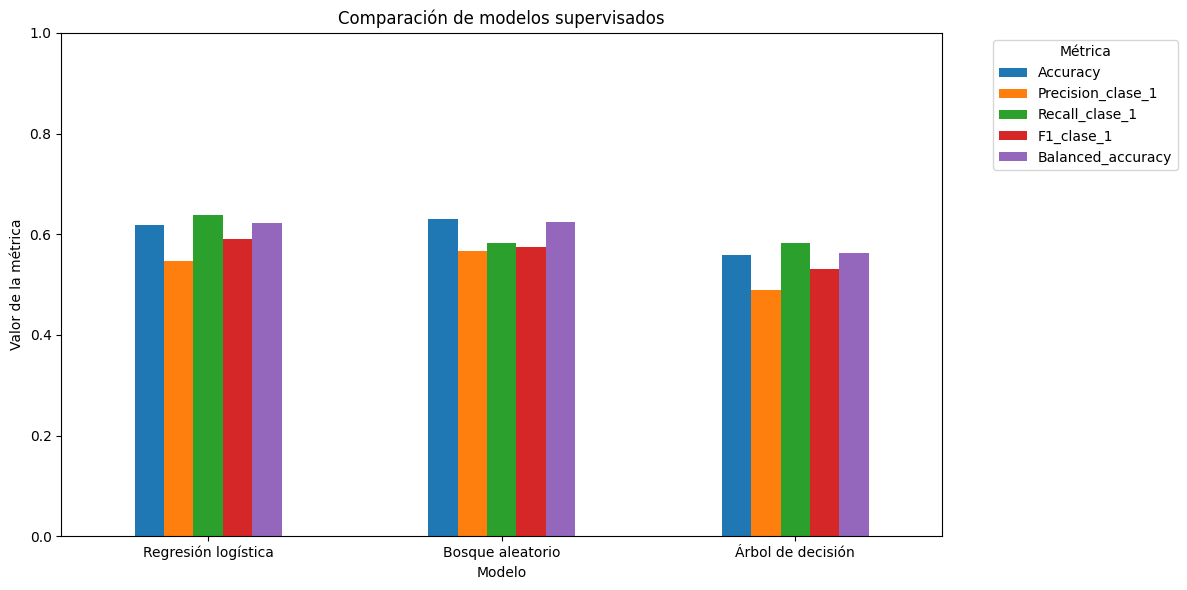

In [12]:
# ============================================================
# 12. Gráfica comparativa de modelos
# ============================================================

metricas_para_graficar = ["Accuracy", "Precision_clase_1", "Recall_clase_1", "F1_clase_1", "Balanced_accuracy"]

comparacion_plot = comparacion_modelos.set_index("Modelo")[metricas_para_graficar]

ax = comparacion_plot.plot(kind="bar", figsize=(12, 6))
plt.title("Comparación de modelos supervisados")
plt.xlabel("Modelo")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 13. Selección del modelo final

El modelo final se selecciona con base en el mejor `F1_clase_1`.

¿Por qué?

Porque `F1_clase_1` equilibra:

- La capacidad de detectar clientes que abandonan (`recall`).
- La confiabilidad de las alertas positivas (`precision`).

Esta decisión es más adecuada que elegir solo por `accuracy`, porque el objetivo principal es identificar clientes en riesgo de abandono.

In [13]:
# ============================================================
# 13. Selección del modelo final
# ============================================================

modelo_seleccionado_nombre = comparacion_modelos.iloc[0]["Modelo"]
modelo_final = modelos_entrenados[modelo_seleccionado_nombre]
y_pred = predicciones_modelos[modelo_seleccionado_nombre]

print("Modelo seleccionado:", modelo_seleccionado_nombre)
print("Criterio principal: mayor F1-score para la clase 1 (cliente que sí abandona).")

display(comparacion_modelos.iloc[[0]])

Modelo seleccionado: Regresión logística
Criterio principal: mayor F1-score para la clase 1 (cliente que sí abandona).


,Modelo,Accuracy,Precision_clase_1,Recall_clase_1,F1_clase_1,Balanced_accuracy
0,Regresión logística,0.619048,0.547619,0.638889,0.589744,0.621528


## 14. Porcentaje de acierto y error del modelo final

El porcentaje de acierto general se calcula con `accuracy`.

También se calcula el porcentaje de error para que el aprendiz pueda interpretar el resultado de forma sencilla.

In [14]:
# ============================================================
# 14. Porcentaje de acierto y error
# ============================================================

accuracy = accuracy_score(y_test, y_pred)
porcentaje_acierto = accuracy * 100
porcentaje_error = (1 - accuracy) * 100

print(f"Modelo final: {modelo_seleccionado_nombre}")
print(f"Porcentaje de acierto general: {porcentaje_acierto:.2f}%")
print(f"Porcentaje de error general: {porcentaje_error:.2f}%")

resultados_prediccion = pd.DataFrame({
    "Real": y_test.values,
    "Prediccion": y_pred
})

resultados_prediccion["Acierto"] = resultados_prediccion["Real"] == resultados_prediccion["Prediccion"]

display(resultados_prediccion.head(10))

Modelo final: Regresión logística
Porcentaje de acierto general: 61.90%
Porcentaje de error general: 38.10%


,Real,Prediccion,Acierto
0,1,1,True
1,0,1,False
2,0,0,True
3,1,0,False
4,0,0,True
5,1,0,False
6,0,0,True
7,0,0,True
8,1,0,False
9,1,1,True


## 15. Gráfica de aciertos y errores

Esta gráfica muestra cuántos casos fueron clasificados correctamente y cuántos fueron clasificados incorrectamente.

,Resultado,Cantidad,Porcentaje
0,Aciertos,52,61.904762
1,Errores,32,38.095238


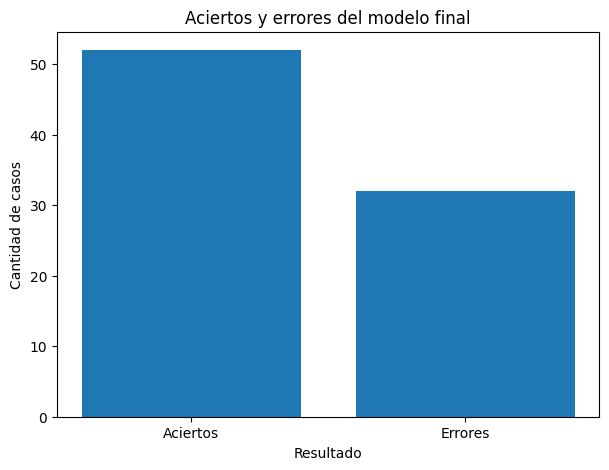

In [15]:
# ============================================================
# 15. Gráfica de aciertos y errores
# ============================================================

aciertos = int(resultados_prediccion["Acierto"].sum())
errores = int((~resultados_prediccion["Acierto"]).sum())
total = len(resultados_prediccion)

resumen_aciertos = pd.DataFrame({
    "Resultado": ["Aciertos", "Errores"],
    "Cantidad": [aciertos, errores],
    "Porcentaje": [aciertos / total * 100, errores / total * 100]
})

display(resumen_aciertos)

plt.figure(figsize=(7, 5))
plt.bar(resumen_aciertos["Resultado"], resumen_aciertos["Cantidad"])
plt.title("Aciertos y errores del modelo final")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de casos")
plt.show()

## 16. Matriz de confusión en cantidades

La matriz de confusión permite saber en qué acierta y en qué se equivoca el modelo.

| Resultado | Explicación |
|---|---|
| Verdadero negativo | No abandonó y el modelo dijo no abandona |
| Falso positivo | No abandonó, pero el modelo dijo sí abandona |
| Falso negativo | Sí abandonó, pero el modelo dijo no abandona |
| Verdadero positivo | Sí abandonó y el modelo dijo sí abandona |

En abandono de clientes, el falso negativo es delicado porque representa un cliente que sí abandonó y el modelo no detectó.

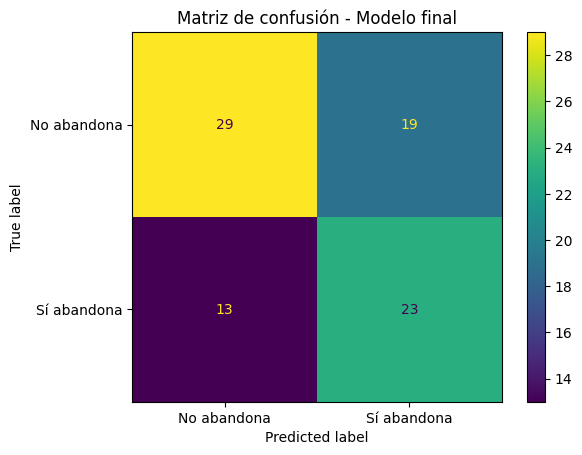

Matriz de confusión en cantidades:
[[29 19]
 [13 23]]


In [16]:
# ============================================================
# 16. Matriz de confusión en cantidades
# ============================================================

matriz = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["No abandona", "Sí abandona"]
)

disp.plot()
plt.title("Matriz de confusión - Modelo final")
plt.show()

print("Matriz de confusión en cantidades:")
print(matriz)

## 17. Matriz de confusión en porcentaje

La matriz en porcentaje ayuda a interpretar mejor el comportamiento del modelo dentro de cada clase real.

Por ejemplo, permite saber qué porcentaje de clientes que realmente abandonaron fue detectado correctamente.

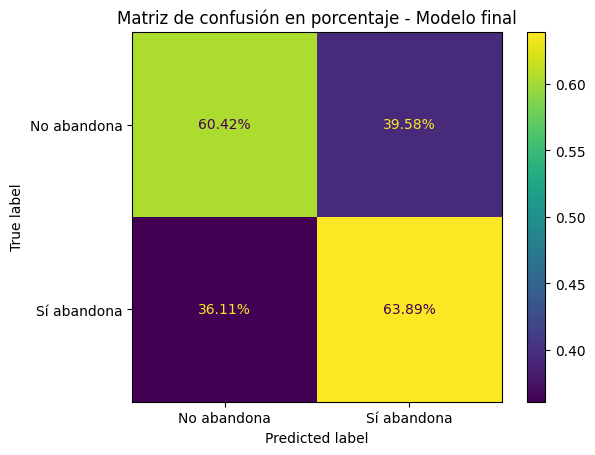

Matriz de confusión en porcentaje:
[[60.42 39.58]
 [36.11 63.89]]


In [17]:
# ============================================================
# 17. Matriz de confusión en porcentaje
# ============================================================

matriz_porcentaje = confusion_matrix(y_test, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_porcentaje,
    display_labels=["No abandona", "Sí abandona"]
)

disp.plot(values_format=".2%")
plt.title("Matriz de confusión en porcentaje - Modelo final")
plt.show()

print("Matriz de confusión en porcentaje:")
print(np.round(matriz_porcentaje * 100, 2))

## 18. Reporte de clasificación

El reporte muestra las principales métricas para cada clase:

- `precision`
- `recall`
- `f1-score`
- `support`

La clase más importante en este caso es `Sí abandona`, porque representa los clientes que la empresa desea detectar para tomar acciones preventivas.

In [18]:
# ============================================================
# 18. Reporte de clasificación
# ============================================================

print(classification_report(
    y_test,
    y_pred,
    target_names=["No abandona", "Sí abandona"],
    zero_division=0
))

              precision    recall  f1-score   support

 No abandona       0.69      0.60      0.64        48
 Sí abandona       0.55      0.64      0.59        36

    accuracy                           0.62        84
   macro avg       0.62      0.62      0.62        84
weighted avg       0.63      0.62      0.62        84



## 19. Comparación entrenamiento vs prueba

Esta comparación permite revisar si el modelo se comporta de manera similar con los datos que usó para aprender y con datos nuevos.

Interpretación:

| Situación | Posible conclusión |
|---|---|
| Entrenamiento alto y prueba bajo | Puede haber sobreajuste |
| Entrenamiento y prueba bajos | Puede haber bajo aprendizaje |
| Entrenamiento y prueba similares | El modelo podría generalizar mejor |

,Conjunto,Accuracy,Precision_clase_1,Recall_clase_1,F1_clase_1
0,Entrenamiento,0.717262,0.652174,0.729167,0.688525
1,Prueba,0.619048,0.547619,0.638889,0.589744


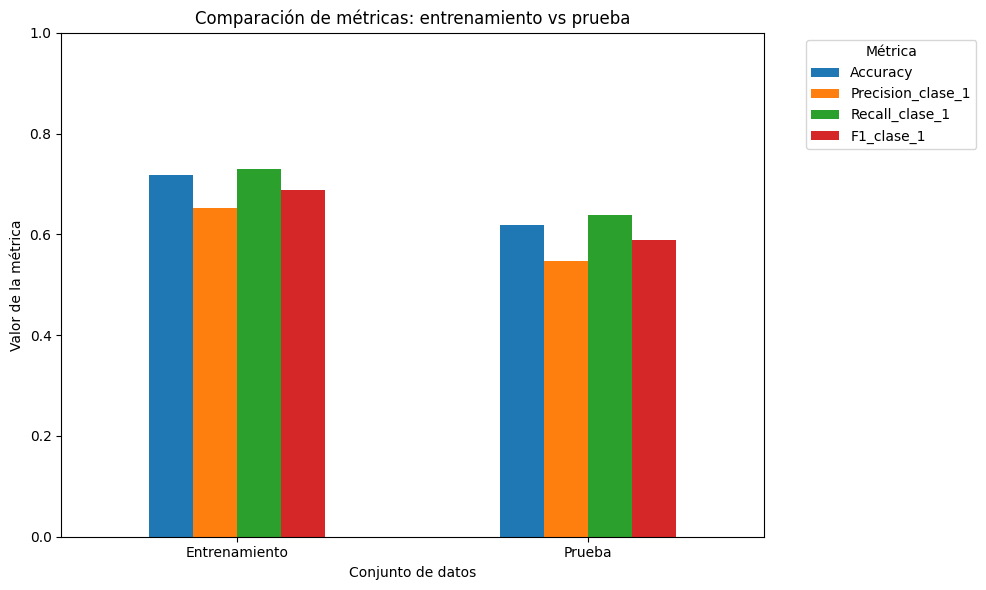

In [19]:
# ============================================================
# 19. Comparación entrenamiento vs prueba
# ============================================================

y_pred_train = modelo_final.predict(X_train)
y_pred_test = modelo_final.predict(X_test)

metricas_train_test = pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Accuracy": [
        accuracy_score(y_train, y_pred_train),
        accuracy_score(y_test, y_pred_test)
    ],
    "Precision_clase_1": [
        precision_score(y_train, y_pred_train, zero_division=0),
        precision_score(y_test, y_pred_test, zero_division=0)
    ],
    "Recall_clase_1": [
        recall_score(y_train, y_pred_train, zero_division=0),
        recall_score(y_test, y_pred_test, zero_division=0)
    ],
    "F1_clase_1": [
        f1_score(y_train, y_pred_train, zero_division=0),
        f1_score(y_test, y_pred_test, zero_division=0)
    ]
})

display(metricas_train_test)

metricas_train_test.set_index("Conjunto").plot(kind="bar", figsize=(10, 6))
plt.title("Comparación de métricas: entrenamiento vs prueba")
plt.xlabel("Conjunto de datos")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 19.1 Curva de aprendizaje del modelo final

Esta sección se incluye para que el aprendiz no se quede solo con una métrica final. La **curva de aprendizaje** permite observar cómo cambia el desempeño del modelo cuando se entrena con diferentes cantidades de datos.

### ¿Qué compara esta gráfica?

La gráfica compara dos comportamientos:

| Curva | Qué representa | Cómo interpretarla |
|---|---|---|
| **Entrenamiento** | Desempeño del modelo con los datos que usa para aprender | Suele ser más alto porque el modelo ya vio esos datos |
| **Validación** | Desempeño del modelo con partes de los datos que se apartan temporalmente durante la validación cruzada | Se parece más a lo que podría pasar con datos nuevos |

### ¿Para qué sirve?

Sirve para responder preguntas como:

1. ¿El modelo mejora cuando recibe más datos?
2. ¿El modelo está memorizando el entrenamiento?
3. ¿El modelo funciona parecido cuando se valida con datos no vistos?
4. ¿Puede necesitar más registros?
5. ¿Puede necesitar mejores variables?

### ¿Por qué usamos F1-score?

En esta guía se usa **F1-score** porque el problema busca detectar clientes que sí abandonan, es decir, la clase `Abandono = 1`.

El F1-score combina dos ideas:

- **Precision:** qué tan confiables son las alertas de abandono.
- **Recall:** cuántos clientes que realmente abandonan logra detectar el modelo.

Por eso es una métrica útil cuando no basta con acertar en general.


,Cantidad_datos_entrenamiento,F1_entrenamiento_promedio,F1_validacion_promedio
0,53,0.825732,0.447802
1,107,0.735484,0.463818
2,160,0.697455,0.554519
3,214,0.684489,0.569988
4,268,0.692380,0.579050


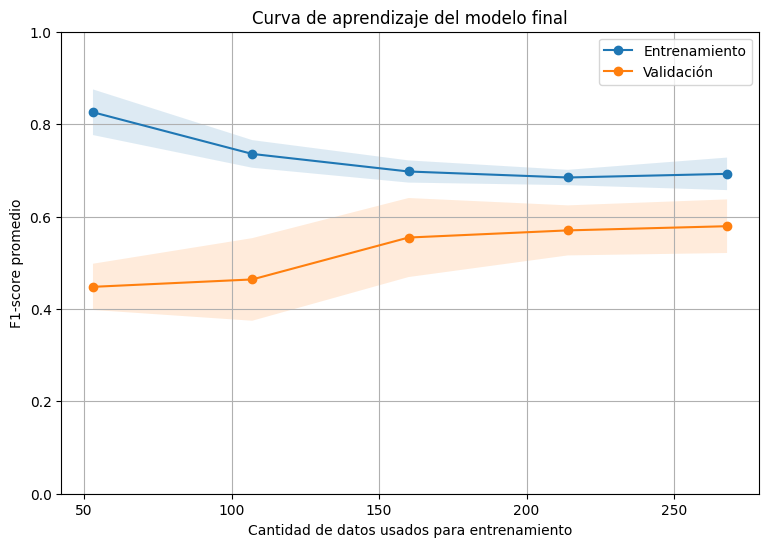

In [20]:
# ============================================================
# 19.1 Curva de aprendizaje del modelo final
# ============================================================

from sklearn.model_selection import learning_curve, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=modelo_final,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring="f1",
    n_jobs=None
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
validation_mean = validation_scores.mean(axis=1)
validation_std = validation_scores.std(axis=1)

curva_aprendizaje = pd.DataFrame({
    "Cantidad_datos_entrenamiento": train_sizes,
    "F1_entrenamiento_promedio": train_mean,
    "F1_validacion_promedio": validation_mean
})

display(curva_aprendizaje)

plt.figure(figsize=(9, 6))
plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
plt.plot(train_sizes, validation_mean, marker="o", label="Validación")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)
plt.fill_between(train_sizes, validation_mean - validation_std, validation_mean + validation_std, alpha=0.15)
plt.title("Curva de aprendizaje del modelo final")
plt.xlabel("Cantidad de datos usados para entrenamiento")
plt.ylabel("F1-score promedio")
plt.ylim(0, 1)
plt.grid(True)
plt.legend()
plt.show()


In [21]:
# ============================================================
# 19.1.1 Análisis automático de la curva de aprendizaje
# ============================================================

f1_train_final = train_mean[-1]
f1_val_final = validation_mean[-1]
brecha_aprendizaje = f1_train_final - f1_val_final

print("Análisis de la curva de aprendizaje")
print("-----------------------------------")
print(f"F1 entrenamiento final: {f1_train_final:.3f}")
print(f"F1 validación final: {f1_val_final:.3f}")
print(f"Diferencia entrenamiento-validación: {brecha_aprendizaje:.3f}")

if brecha_aprendizaje > 0.15:
    print("Interpretación: existe una diferencia importante entre entrenamiento y validación.")
    print("Esto puede indicar posible sobreajuste: el modelo aprende bien el entrenamiento, pero baja en validación.")
elif f1_train_final < 0.50 and f1_val_final < 0.50:
    print("Interpretación: ambas curvas son bajas.")
    print("Esto puede indicar bajo aprendizaje: el modelo no está encontrando patrones suficientes.")
else:
    print("Interpretación: las curvas no muestran una brecha crítica.")
    print("El modelo parece tener un comportamiento relativamente estable entre entrenamiento y validación.")


Análisis de la curva de aprendizaje
-----------------------------------
F1 entrenamiento final: 0.692
F1 validación final: 0.579
Diferencia entrenamiento-validación: 0.113
Interpretación: las curvas no muestran una brecha crítica.
El modelo parece tener un comportamiento relativamente estable entre entrenamiento y validación.


### Explicación de los resultados de la curva de aprendizaje

Después de ejecutar la curva, se deben observar tres elementos:

| Elemento observado | Pregunta que responde | Interpretación |
|---|---|---|
| Valor de entrenamiento | ¿Qué tan bien aprende con los datos conocidos? | Si es muy alto, el modelo puede estar ajustándose mucho al entrenamiento |
| Valor de validación | ¿Qué tan bien se comporta con datos no usados directamente para entrenar? | Si es bajo, el modelo puede fallar al generalizar |
| Brecha entre curvas | ¿Hay mucha diferencia entre aprender y generalizar? | Una brecha grande puede indicar sobreajuste |

### Ejemplo de interpretación para el informe

> La curva de aprendizaje muestra que el modelo mantiene una diferencia de ___ entre el F1-score de entrenamiento y el F1-score de validación. Esta comparación permite revisar si el modelo está aprendiendo patrones generales o si está memorizando los datos de entrenamiento. Si la curva de validación se mantiene cercana a la de entrenamiento, el modelo tiene un comportamiento más estable. Si la curva de validación queda muy por debajo, puede existir sobreajuste.

### Idea clave para el aprendiz

La curva de aprendizaje no dice por sí sola si el modelo es “bueno” o “malo”. Sirve para observar **cómo aprende** el modelo a medida que recibe más datos y si su desempeño se mantiene cuando se valida con datos que no usa directamente para entrenar.


### ¿Cómo interpretar esta curva?

Usa esta guía:

| Situación en la gráfica | Qué puede significar | Qué decisión se puede tomar |
|---|---|---|
| Entrenamiento alto y validación mucho más baja | Posible sobreajuste | Simplificar modelo, revisar variables, aumentar datos o regularizar |
| Entrenamiento bajo y validación baja | Bajo aprendizaje | Revisar variables, crear mejores atributos, probar otro modelo |
| Entrenamiento y validación cercanos con valores aceptables | Comportamiento estable | El modelo generaliza de forma más razonable |
| Validación sube al aumentar datos | Más datos podrían ayudar | Conseguir más registros o mejorar recolección |
| Validación se estanca baja | Más datos no bastan | Revisar calidad de variables o el tipo de modelo |

Esta curva no reemplaza la matriz de confusión ni las métricas de prueba. Es una ayuda adicional para comprender el comportamiento del modelo durante el aprendizaje.


## 19.2 Curva ROC en entrenamiento y prueba

La **curva ROC** permite observar qué tan bien el modelo separa las dos clases:

- `0`: cliente que no abandona.
- `1`: cliente que sí abandona.

### ¿Qué muestra la curva ROC?

La curva ROC compara dos tasas:

| Concepto | Nombre técnico | Explicación sencilla |
|---|---|---|
| Tasa de verdaderos positivos | TPR / Recall | De los clientes que sí abandonan, cuántos detecta el modelo |
| Tasa de falsos positivos | FPR | De los clientes que no abandonan, cuántos fueron marcados incorrectamente como abandono |

La curva permite ver cómo cambia el comportamiento del modelo cuando se modifica el umbral de decisión.

### ¿Qué es el AUC?

El **AUC** resume la curva ROC en un valor entre `0` y `1`.

| AUC aproximado | Interpretación |
|---:|---|
| 0.50 | El modelo separa las clases casi como si adivinara |
| 0.60 - 0.70 | Separación baja o moderada |
| 0.70 - 0.80 | Separación aceptable |
| 0.80 - 0.90 | Buena separación |
| 0.90 - 1.00 | Separación muy alta; revisar posible sobreajuste si entrenamiento es mucho mayor que prueba |

### ¿Por qué graficar entrenamiento y prueba?

Porque permite comparar si el modelo se comporta parecido con los datos usados para aprender y con los datos que no vio durante el entrenamiento.

Si el AUC de entrenamiento es mucho mayor que el AUC de prueba, puede existir sobreajuste.


,Conjunto,AUC
0,Entrenamiento,0.785916
1,Prueba,0.651620


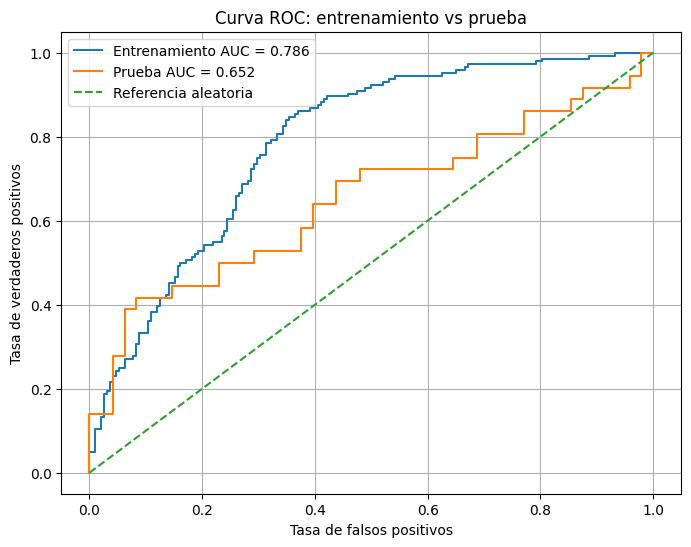

Análisis de la curva ROC
------------------------
AUC en entrenamiento: 0.786
AUC en prueba: 0.652
Diferencia AUC entrenamiento-prueba: 0.134
Interpretación: el AUC de prueba muestra una separación moderada.
La diferencia entre entrenamiento y prueba no parece crítica.


In [22]:
# ============================================================
# 19.2 Curva ROC: entrenamiento vs prueba
# ============================================================

from sklearn.metrics import roc_curve, auc

if hasattr(modelo_final, "predict_proba"):
    prob_train = modelo_final.predict_proba(X_train)[:, 1]
    prob_test = modelo_final.predict_proba(X_test)[:, 1]

    fpr_train, tpr_train, _ = roc_curve(y_train, prob_train)
    fpr_test, tpr_test, _ = roc_curve(y_test, prob_test)

    auc_train = auc(fpr_train, tpr_train)
    auc_test = auc(fpr_test, tpr_test)
    diferencia_auc = auc_train - auc_test

    resumen_auc = pd.DataFrame({
        "Conjunto": ["Entrenamiento", "Prueba"],
        "AUC": [auc_train, auc_test]
    })

    display(resumen_auc)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr_train, tpr_train, label=f"Entrenamiento AUC = {auc_train:.3f}")
    plt.plot(fpr_test, tpr_test, label=f"Prueba AUC = {auc_test:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Referencia aleatoria")
    plt.title("Curva ROC: entrenamiento vs prueba")
    plt.xlabel("Tasa de falsos positivos")
    plt.ylabel("Tasa de verdaderos positivos")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("Análisis de la curva ROC")
    print("------------------------")
    print(f"AUC en entrenamiento: {auc_train:.3f}")
    print(f"AUC en prueba: {auc_test:.3f}")
    print(f"Diferencia AUC entrenamiento-prueba: {diferencia_auc:.3f}")

    if auc_test < 0.60:
        print("Interpretación: el AUC de prueba es bajo. El modelo separa débilmente las clases.")
    elif auc_test < 0.70:
        print("Interpretación: el AUC de prueba muestra una separación moderada.")
    else:
        print("Interpretación: el AUC de prueba muestra una separación aceptable o buena.")

    if diferencia_auc > 0.15:
        print("Advertencia: el AUC de entrenamiento supera bastante al de prueba. Puede existir sobreajuste.")
    else:
        print("La diferencia entre entrenamiento y prueba no parece crítica.")
else:
    print("El modelo seleccionado no permite calcular predict_proba. No se puede graficar la curva ROC con este modelo.")


### Interpretación esperada de la curva ROC

La curva ROC debe leerse con cuidado. No reemplaza la matriz de confusión, pero ayuda a entender si el modelo logra separar clientes con riesgo de abandono y clientes sin riesgo.

| Resultado observado | Interpretación |
|---|---|
| AUC prueba cercano a 0.5 | El modelo casi no separa las clases |
| AUC prueba mayor que 0.7 | El modelo separa mejor las clases |
| AUC entrenamiento mucho mayor que AUC prueba | Posible sobreajuste |
| AUC entrenamiento y prueba similares | Comportamiento más estable |
| Curva cerca de la diagonal | Desempeño parecido al azar |
| Curva cerca de la esquina superior izquierda | Mejor separación de clases |

### Diferencia entre curva ROC y matriz de confusión

| Elemento | Qué responde |
|---|---|
| Matriz de confusión | ¿Cuántos clientes clasificó bien o mal con un umbral específico? |
| Curva ROC | ¿Qué tan bien separa las clases si se cambia el umbral de decisión? |
| AUC | ¿Qué tan buena es la separación global entre clases? |

### Ejemplo de conclusión para el informe

> La curva ROC permitió comparar el desempeño del modelo en entrenamiento y prueba. El AUC de prueba fue de ____, lo que indica que el modelo tiene una capacidad de separación ____ entre clientes que abandonan y clientes que no abandonan. Además, la diferencia entre el AUC de entrenamiento y el AUC de prueba fue de ____, por lo que se puede concluir que ____.

### Idea clave para el aprendiz

En problemas de abandono, la curva ROC se interpreta junto con la matriz de confusión, `precision`, `recall` y `F1-score`, porque el objetivo no es solo acertar en general, sino detectar correctamente a los clientes que sí podrían abandonar.


## 20. Predicción con un cliente nuevo definido manualmente

En esta sección se crea un cliente nuevo con valores ingresados en una tabla.

El modelo predice si ese cliente podría abandonar y muestra la probabilidad estimada de abandono.

Este bloque no requiere `ipywidgets`, por lo tanto funciona en la mayoría de entornos.

In [23]:
# ============================================================
# 20. Predicción con cliente nuevo manual
# ============================================================

def preparar_cliente_nuevo(cliente_dict):
    """
    Convierte un diccionario en DataFrame y normaliza categorías para que coincidan con el pipeline.
    """
    cliente_df = pd.DataFrame([cliente_dict])
    cliente_df = normalizar_categorias_clientes(cliente_df)
    return cliente_df

def predecir_cliente(cliente_dict, modelo=modelo_final):
    """
    Recibe los datos de un cliente, realiza predicción y retorna una tabla de resultados.
    """
    cliente_df = preparar_cliente_nuevo(cliente_dict)

    prediccion = int(modelo.predict(cliente_df)[0])

    if hasattr(modelo, "predict_proba"):
        probabilidades = modelo.predict_proba(cliente_df)[0]
        prob_no_abandona = float(probabilidades[0] * 100)
        prob_abandona = float(probabilidades[1] * 100)
    else:
        prob_no_abandona = np.nan
        prob_abandona = np.nan

    resultado = "Sí abandona" if prediccion == 1 else "No abandona"

    salida = pd.DataFrame([{
        "Prediccion": prediccion,
        "Interpretacion": resultado,
        "Probabilidad_no_abandona_%": round(prob_no_abandona, 2),
        "Probabilidad_abandona_%": round(prob_abandona, 2)
    }])

    return salida, cliente_df

cliente_nuevo = {
    "Edad": 35,
    "IngresoMensual": 2800,
    "CantidadCompras": 6,
    "ComprasUltimos12M": 3,
    "AntiguedadMeses": 24,
    "QuejasUltimos6M": 2,
    "DiasDesdeUltimaCompra": 75,
    "VisitasWebUltimoMes": 4,
    "TiempoPromedioSesionMin": 6.5,
    "CuponesUsados": 1,
    "Ciudad": "Bogotá",
    "CanalPreferido": "Web",
    "ZonaResidencia": "Urbana",
    "Segmento": "Medio",
    "Satisfaccion": "Media",
    "CodigoCampania": "CAMP_01"
}

resultado_cliente, cliente_df = predecir_cliente(cliente_nuevo)

print("Datos del cliente nuevo:")
display(cliente_df)

print("Resultado de la predicción:")
display(resultado_cliente)

Datos del cliente nuevo:


,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania
0,35,2800,6,3,24,2,75,4,6.5,1,Bogotá,Web,Urbana,Medio,Media,CAMP_01


Resultado de la predicción:


,Prediccion,Interpretacion,Probabilidad_no_abandona_%,Probabilidad_abandona_%
0,1,Sí abandona,24.09,75.91


## 21. Gráfica de probabilidad de abandono del cliente nuevo

La siguiente gráfica muestra la probabilidad estimada de que el cliente abandone o no abandone.

,Clase,Probabilidad
0,No abandona,24.09
1,Sí abandona,75.91


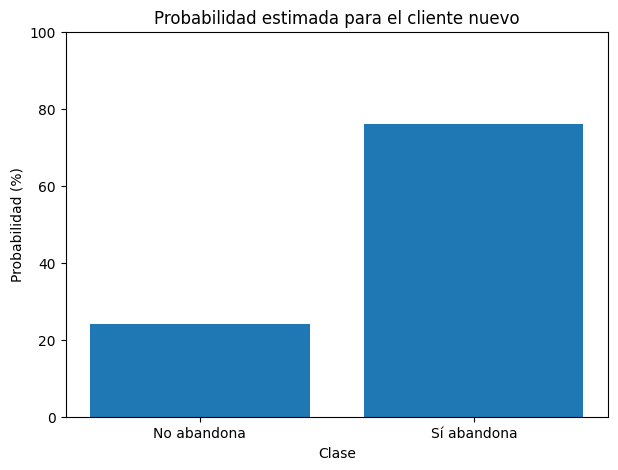

In [24]:
# ============================================================
# 21. Gráfica de probabilidad del cliente nuevo
# ============================================================

probabilidades_cliente = pd.DataFrame({
    "Clase": ["No abandona", "Sí abandona"],
    "Probabilidad": [
        resultado_cliente.loc[0, "Probabilidad_no_abandona_%"],
        resultado_cliente.loc[0, "Probabilidad_abandona_%"]
    ]
})

display(probabilidades_cliente)

plt.figure(figsize=(7, 5))
plt.bar(probabilidades_cliente["Clase"], probabilidades_cliente["Probabilidad"])
plt.title("Probabilidad estimada para el cliente nuevo")
plt.xlabel("Clase")
plt.ylabel("Probabilidad (%)")
plt.ylim(0, 100)
plt.show()

## 22. Script opcional: solicitar datos por teclado

Este bloque permite que el aprendiz ingrese los datos de un cliente por teclado.

Para evitar que el notebook se detenga durante una ejecución automática, el bloque está desactivado inicialmente.

Para usarlo:

1. Cambia `ACTIVAR_INGRESO_POR_TECLADO = False` por `True`.
2. Ejecuta la celda.
3. Ingresa los valores solicitados.
4. El modelo mostrará si el cliente abandona o no y su porcentaje de probabilidad.

In [25]:
# ============================================================
# 22. Script opcional para solicitar datos por teclado
# ============================================================

ACTIVAR_INGRESO_POR_TECLADO = False

def pedir_entero(mensaje):
    while True:
        try:
            return int(input(mensaje))
        except ValueError:
            print("Ingresa un número entero válido.")

def pedir_decimal(mensaje):
    while True:
        try:
            return float(input(mensaje))
        except ValueError:
            print("Ingresa un número decimal válido.")

def pedir_texto(mensaje, opciones=None):
    while True:
        valor = input(mensaje).strip()
        if opciones is None or valor in opciones:
            return valor
        print("Valor no válido. Opciones permitidas:", opciones)

if ACTIVAR_INGRESO_POR_TECLADO:
    print("Ingreso de datos de cliente nuevo")
    print("--------------------------------")

    cliente_teclado = {
        "Edad": pedir_entero("Edad: "),
        "IngresoMensual": pedir_entero("Ingreso mensual: "),
        "CantidadCompras": pedir_entero("Cantidad histórica de compras: "),
        "ComprasUltimos12M": pedir_entero("Compras últimos 12 meses: "),
        "AntiguedadMeses": pedir_entero("Antigüedad en meses: "),
        "QuejasUltimos6M": pedir_entero("Quejas últimos 6 meses: "),
        "DiasDesdeUltimaCompra": pedir_entero("Días desde última compra: "),
        "VisitasWebUltimoMes": pedir_entero("Visitas web último mes: "),
        "TiempoPromedioSesionMin": pedir_decimal("Tiempo promedio de sesión en minutos: "),
        "CuponesUsados": pedir_entero("Cupones usados: "),
        "Ciudad": pedir_texto("Ciudad: "),
        "CanalPreferido": pedir_texto("Canal preferido: "),
        "ZonaResidencia": pedir_texto("Zona de residencia: "),
        "Segmento": pedir_texto("Segmento (Básico/Medio/Premium): ", ["Básico", "Basico", "Medio", "Premium"]),
        "Satisfaccion": pedir_texto("Satisfacción (Baja/Media/Alta): ", ["Baja", "Media", "Alta"]),
        "CodigoCampania": pedir_texto("Código campaña: ")
    }

    resultado_teclado, cliente_teclado_df = predecir_cliente(cliente_teclado)

    print("\nCliente ingresado:")
    display(cliente_teclado_df)

    print("Resultado de la predicción:")
    display(resultado_teclado)
else:
    print("El ingreso por teclado está desactivado.")
    print("Para usarlo, cambia ACTIVAR_INGRESO_POR_TECLADO = True y ejecuta nuevamente esta celda.")

El ingreso por teclado está desactivado.
Para usarlo, cambia ACTIVAR_INGRESO_POR_TECLADO = True y ejecuta nuevamente esta celda.


## 23. Guardar modelo final y resultados

Este bloque guarda:

- el modelo final entrenado;
- la comparación de modelos;
- los resultados de predicción del cliente nuevo.

Esto permite reutilizar el modelo posteriormente.

In [26]:
# ============================================================
# 23. Guardar modelo y resultados
# ============================================================

with open("modelo_final_abandono.pkl", "wb") as archivo_modelo:
    pickle.dump(modelo_final, archivo_modelo)

comparacion_modelos.to_csv("comparacion_modelos_guia3.csv", index=False)
resultado_cliente.to_csv("prediccion_cliente_nuevo.csv", index=False)

with open("prediccion_cliente_nuevo.json", "w", encoding="utf-8") as archivo_json:
    json.dump(resultado_cliente.to_dict(orient="records"), archivo_json, ensure_ascii=False, indent=4)

print("Archivos generados:")
print("- modelo_final_abandono.pkl")
print("- comparacion_modelos_guia3.csv")
print("- prediccion_cliente_nuevo.csv")
print("- prediccion_cliente_nuevo.json")

Archivos generados:
- modelo_final_abandono.pkl
- comparacion_modelos_guia3.csv
- prediccion_cliente_nuevo.csv
- prediccion_cliente_nuevo.json


## 24. Conclusión modelo para el informe técnico

El aprendiz puede usar esta estructura para redactar su conclusión, ajustando los valores obtenidos en su ejecución:

> Se entrenaron y compararon varios modelos supervisados para predecir el abandono de clientes. El modelo seleccionado fue el que presentó mejor equilibrio entre precision y recall para la clase `Abandono = 1`, usando como criterio principal el F1-score de la clase positiva.
>
> El modelo fue evaluado con datos de prueba que no se usaron durante el entrenamiento. Se calculó el porcentaje general de acierto, la matriz de confusión y las métricas de clasificación. La matriz de confusión permitió identificar aciertos, falsos positivos y falsos negativos.
>
> Además, se realizó una prueba con un cliente nuevo ingresado manualmente, obteniendo una predicción y una probabilidad estimada de abandono. Este resultado debe interpretarse como apoyo a la toma de decisiones y no como una decisión automática definitiva.